# Split by dataset + percentage

`strategy="by_dataset"` combined with `percentage` further splits each dataset
into multiple chunks based on the fraction of files per chunk.

- `percentage=50` → 2 chunks per dataset (50% of files each)
- `percentage=25` → 4 chunks per dataset
- `percentage=10` → 10 chunks per dataset

The value must divide 100 evenly (10, 20, 25, 50, ...).

**Trade-off:** maximum fault tolerance — only the failed chunk needs to rerun.
However, more chunks mean more cache reads/writes and more scheduling overhead,
especially with Dask on lxplus where each chunk submission has HTCondor overhead.

In [1]:
import sys
sys.path.insert(0, "..")

from coffea_workflow import Step, Workflow, Fileset, Analysis, Plotting, RunConfig, ExecutorConfig, run
from coffea_workflow import facilities
from analysis import get_fileset, run_analysis, plot_results

In [2]:
step_fileset = Step(name="Fileset", step_type=Fileset, builder=get_fileset)
step_analysis = Step(name="Analysis", step_type=Analysis, builder=run_analysis)
step_plotting = Step(name="Plotting", step_type=Plotting, builder=plot_results)

workflow = Workflow()
workflow.add(step_fileset)
workflow.add(step_analysis, depends_on=[step_fileset])
workflow.add(step_plotting, depends_on=[step_analysis])

Step(name='Plotting', step_type=<class 'coffea_workflow.artifacts.Plotting'>, builder=<function plot_results at 0x7f562df42c00>, builder_params=None, facility=None, executor_config=None, input=None, output=None)

Workflow DAG:
  [0] Fileset -> Fileset builder=<function get_fileset at 0x7f562df42660>
  [1] Analysis -> Analysis builder=<function run_analysis at 0x7f562df427a0>
  [2] Plotting -> Plotting builder=<function plot_results at 0x7f562df42c00>
Edges:
  Fileset -> Analysis
  Analysis -> Plotting
Executing step 'Fileset' of type 'Fileset' with the user code <function get_fileset at 0x7f562df42660> and user parameters None
Extracted from cache: .cache_by_dataset_50pct/Fileset/22c2cc185640e94941a58e99ac76a71eff60afb8890cd48945c40208ad50cd89
  -> materialized at .cache_by_dataset_50pct/Fileset/22c2cc185640e94941a58e99ac76a71eff60afb8890cd48945c40208ad50cd89
Executing step 'Analysis' of type 'Analysis' with the user code <function run_analysis at 0x7f562df427a0> and user parameters None
Extracted from cache: .cache_by_dataset_50pct/Chunking/3bd6d2c95eb2855fecf52e09d2969f615f5fdeb21284eb4d6e8e1d5d21fc735e

Split strategy applied, starting independent processing of 4 fileset subsets...

--------

Output()

/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py:1278: UserWarning: Performed attempt 1 out of 4
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py:1278: UserWarning: Performed attempt 2 out of 4
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py:1278: UserWarning: Performed attempt 3 out of 4
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py:1278: UserWarning: Performed attempt 4 out of 4
  warnings.warn(


loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 490, in _process_worker
    r = call_item()
        ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py", line 1290, in automatic_retries
    raise e
  File "/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py", line 1276, in automatic_retries
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py", line 1360, in metadata_fetcher_root
    with uproot.open(
         ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/uproot/reading.py", line 144, in open
    file = ReadOnlyFile(
           ^^^^^^

Failure caught!
------------------------------------
Processing fileset_chunk_1.json
Extracted from cache: .cache_by_dataset_50pct/ChunkAnalysis/ec3aa0444939209b8d6677e515149c1ac8a26dce639545559281595ffe0448d0
Successfully processed!
------------------------------------
Processing fileset_chunk_2.json
Extracted from cache: .cache_by_dataset_50pct/ChunkAnalysis/c29ec1c12f8b4a6d0b59236797b606c49af980a95a671c4890df6810766edfcb
Successfully processed!
------------------------------------
Processing fileset_chunk_3.json
Extracted from cache: .cache_by_dataset_50pct/ChunkAnalysis/779f57ebc44583ab009784870f4f3304169b30ba774401669315d4b556252a97
Successfully processed!
  -> materialized at .cache_by_dataset_50pct/Analysis/af829d369589e92f54ed6fb97c33479dfb18a10803721c01befc641c6a8bc24f
Executing step 'Plotting' of type 'Plotting' with the user code <function plot_results at 0x7f562df42c00> and user parameters None
  -> materialized at .cache_by_dataset_50pct/Plotting/f11779c4df64250ab8c330aef9

{'paths': {'Fileset': PosixPath('.cache_by_dataset_50pct/Fileset/22c2cc185640e94941a58e99ac76a71eff60afb8890cd48945c40208ad50cd89'),
  'Analysis': PosixPath('.cache_by_dataset_50pct/Analysis/af829d369589e92f54ed6fb97c33479dfb18a10803721c01befc641c6a8bc24f'),
  'Plotting': PosixPath('.cache_by_dataset_50pct/Plotting/f11779c4df64250ab8c330aef9ce1d9ecc13707610b186497e16e6a72798239b')},
 'results': {'Fileset': {'SingleMu_0': {'files': {'root://eeeospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A41320F6-C9F9-574C-8DD2-BD98C200E4EE.root': 'Events',
     'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A7FEFB1C-387F-2B4D-A111-C53CC9371EC7.root': 'Events',
     'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAO

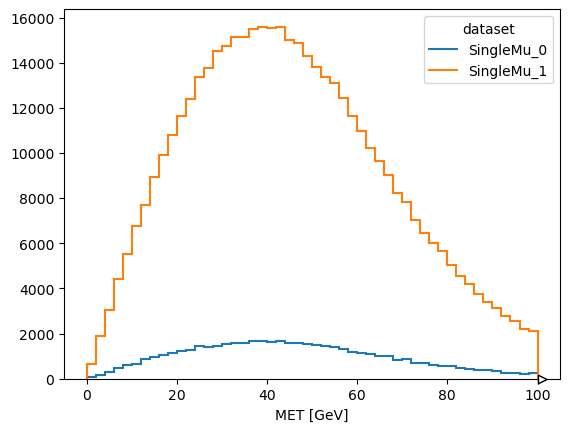

In [3]:
# 2 datasets × 50% = 2 chunks per dataset = 4 chunks total
config = RunConfig(
    strategy="by_dataset",
    percentage=50,
    cache_dir=".cache_by_dataset_50pct",
    facility=facilities.local,
    executor_config=ExecutorConfig(executor_type="FuturesExecutor"),
)

run(workflow, config)